# AirShift — Final Test Evaluation

This notebook evaluates the final XGBoost model on the completely unseen test period.

The final model was trained using the combined training and validation periods, while the test period was kept separate throughout model development and hyperparameter tuning.

The evaluation focuses on the model's ability to detect future air quality deterioration events on unseen data.


## 1. Load the Dataset

In [11]:
from pathlib import Path
import pandas as pd
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
    
)
import matplotlib.pyplot as plt


In [2]:
DATA_PATH = Path("../data/processed/airshift_labeled.csv")
MODEL_PATH = Path("../models/xgboost_final.joblib")

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])

final_xgb = joblib.load(MODEL_PATH)

print("Dataset shape:", df.shape)
print("Final model loaded successfully.")

Dataset shape: (418381, 100)
Final model loaded successfully.


In [3]:
TEST_START = "2016-01-01 00:00:00"

test_mask = df["datetime"] >= TEST_START

test_df = df.loc[test_mask].copy()

print("Test dataset shape:", test_df.shape)
print("Test date range:", test_df["datetime"].min(), "to", test_df["datetime"].max())

Test dataset shape: (121900, 100)
Test date range: 2016-01-01 00:00:00 to 2017-02-28 17:00:00


## 2. Define Test Features and Target

The test features and target are separated for the final evaluation.

The identifier and datetime columns are excluded from the model features, while the `Deterioration` column is used as the target variable.


In [4]:
TARGET = "Deterioration"
EXCLUDED_COLUMNS = ["Deterioration", "No", "datetime"]

X_test = test_df.drop(columns=EXCLUDED_COLUMNS)
y_test = test_df[TARGET]

print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("Number of features:", X_test.shape[1])

Test features shape: (121900, 97)
Test target shape: (121900,)
Number of features: 97


### Findings

The final XGBoost model was evaluated on the completely unseen 2016–2017 test period.

The model achieved performance comparable to the validation results, with no major degradation on the unseen test data. This indicates that the selected model configuration maintained consistent performance when evaluated on a later time period.

The final test results provide the main performance reference for the AirShift model before moving to model interpretation and deployment.


## 3. Final Test Predictions

The final XGBoost model is used to generate predictions on the completely unseen test period.

No model fitting, hyperparameter tuning, or threshold optimization is performed on the test data.


In [5]:
# Generate test predictions
y_test_pred = final_xgb.predict(X_test)
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

print("Test predictions generated successfully.")

Test predictions generated successfully.


## 4. Test Set Evaluation

The final XGBoost model is evaluated on the held-out test set covering observations from January 2016 to February 2017.

The test set was not used during model development or hyperparameter tuning, providing an unbiased evaluation of the final model's performance on unseen data.

The following metrics are calculated:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Proportion of predicted deterioration events that were actual deterioration events.
- **Recall:** Proportion of actual deterioration events correctly detected by the model.
- **F1 Score:** Harmonic mean of precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between deterioration and non-deterioration cases across classification thresholds.
- **PR-AUC:** Measures performance across precision and recall and is particularly useful for evaluating the model's ability to identify deterioration events.

In [6]:
test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob),
    "PR-AUC": average_precision_score(y_test, y_test_prob)
}

test_results = pd.DataFrame(
    [test_metrics],
    index=["Final XGBoost"]
)

test_results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Final XGBoost,0.7368,0.7244,0.7315,0.7279,0.8215,0.8186


## 5. Confusion Matrix

The confusion matrix provides a detailed view of the final model's classification performance on the unseen test set.

It shows the number of correctly and incorrectly classified observations for both deterioration and non-deterioration events, helping assess the model's ability to detect deterioration events and identify missed warnings.

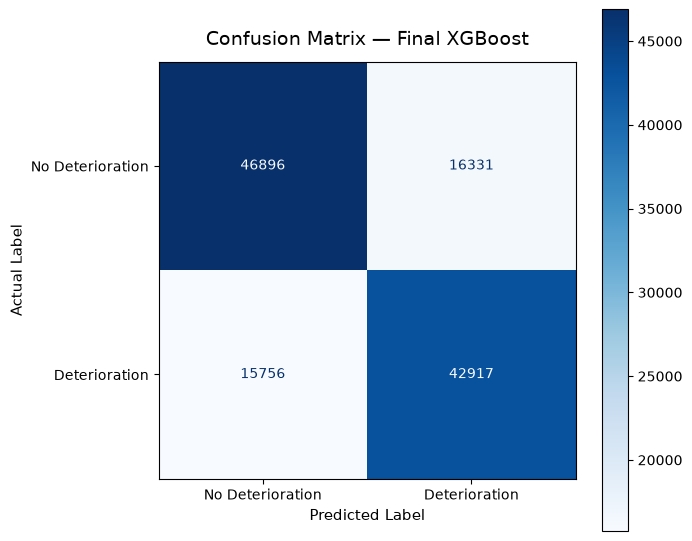

Figure saved to: ..\reports\figures\08_final_test_evaluation\05_confusion_matrix.png


In [7]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create output directory
FIGURES_DIR = Path("../reports/figures/08_final_test_evaluation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Deterioration", "Deterioration"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

ax.set_title(
    "Confusion Matrix — Final XGBoost",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label", fontsize=11)

plt.tight_layout()

# Save figure
FIGURE_PATH = FIGURES_DIR / "05_confusion_matrix.png"
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {FIGURE_PATH}")

### Confusion Matrix Interpretation

The confusion matrix summarizes four types of classification outcomes:

* **True Negative (TN):** A non-deterioration observation correctly classified as non-deterioration.
* **False Positive (FP):** A non-deterioration observation incorrectly classified as deterioration.
* **False Negative (FN):** A deterioration observation incorrectly classified as non-deterioration.
* **True Positive (TP):** A deterioration observation correctly classified as deterioration.

For an early warning system, false negatives are particularly important because they represent deterioration events that the model failed to detect.


In [8]:
# Extract confusion matrix components

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Results")
print("-" * 30)
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

Confusion Matrix Results
------------------------------
True Negatives (TN):  46,896
False Positives (FP): 16,331
False Negatives (FN): 15,756
True Positives (TP):  42,917


In [9]:
print("### Confusion Matrix Findings")
print()

print(
    f"The final XGBoost model correctly identified {tp:,} "
    f"deterioration events and {tn:,} non-deterioration observations."
)

print(
    f"The model produced {fp:,} false positive predictions "
    f"and {fn:,} false negative predictions."
)

print(
    f"False negatives represent cases where an actual deterioration event "
    f"was not detected by the model."
)

### Confusion Matrix Findings

The final XGBoost model correctly identified 42,917 deterioration events and 46,896 non-deterioration observations.
The model produced 16,331 false positive predictions and 15,756 false negative predictions.
False negatives represent cases where an actual deterioration event was not detected by the model.


### Findings

The confusion matrix results are summarized below:

| Classification Outcome  |  Count | Interpretation                                                         |
| ----------------------- | -----: | ---------------------------------------------------------------------- |
| **True Negative (TN)**  | 46,896 | Non-deterioration observations correctly classified                    |
| **False Positive (FP)** | 16,331 | Non-deterioration observations incorrectly classified as deterioration |
| **False Negative (FN)** | 15,756 | Deterioration events not detected by the model                         |
| **True Positive (TP)**  | 42,917 | Deterioration events correctly detected                                |

The model correctly classified **89,813 observations** as either deterioration or non-deterioration. It produced **32,087 classification errors**, consisting of 16,331 false positives and 15,756 false negatives.

For AirShift, the **15,756 false negatives** are particularly important because they represent deterioration events that were not detected by the model and therefore could correspond to missed early warnings. False positives were slightly more frequent than false negatives, indicating that the model generated somewhat more unnecessary warnings than missed deterioration events.

Overall, the confusion matrix provides a detailed view of the model's classification behavior and complements the aggregate performance metrics reported in the test evaluation.


## 6. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the final XGBoost model's ability to distinguish between deterioration and non-deterioration events across different classification thresholds.

The curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** at different probability thresholds.

The **ROC-AUC** summarizes the model's overall discrimination ability, where a higher value indicates better separ


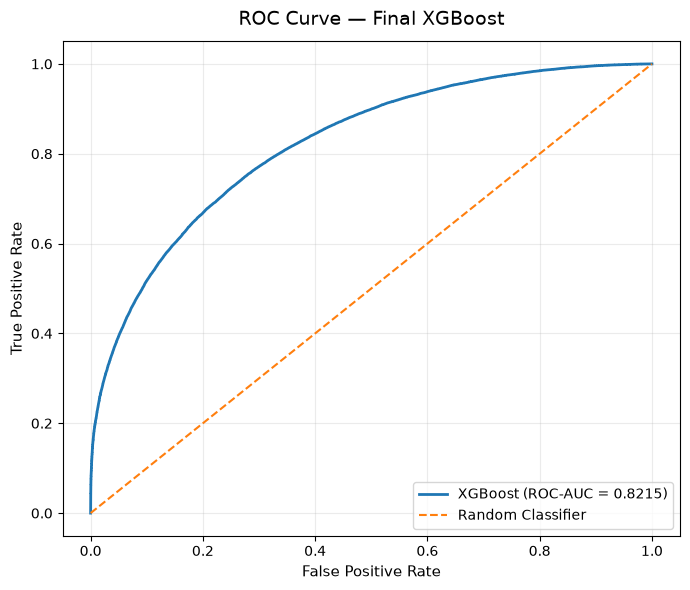

ROC-AUC: 0.8215
Figure saved to: ..\reports\figures\08_final_test_evaluation\06_roc_curve.png


In [10]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_prob)

# Create output directory
FIGURES_DIR = Path("../reports/figures/08_final_test_evaluation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (ROC-AUC = {roc_auc:.4f})"
)

# Random classifier reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

ax.set_title(
    "ROC Curve — Final XGBoost",
    fontsize=14,
    pad=12
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)

ax.legend(loc="lower right")

ax.grid(
    True,
    alpha=0.25
)

plt.tight_layout()

# Save figure
FIGURE_PATH = FIGURES_DIR / "06_roc_curve.png"
plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Figure saved to: {FIGURE_PATH}")

### ROC Curve Interpretation

The ROC curve illustrates the trade-off between correctly detecting deterioration events and generating false positive predictions as the classification threshold changes.

A model with stronger discrimination produces a curve that remains above the random-classifier reference line and approaches the upper-left region of the plot.

For the final XGBoost model, the **ROC-AUC on the unseen test set is 0.8215**, indicating that the model has a good ability to distinguish between deterioration and non-deterioration observations across different classification thresholds.


### Findings

The final XGBoost model achieved a **ROC-AUC of 0.8215** on the unseen test set.

This indicates that the model has a strong ability to discriminate between deterioration and non-deterioration observations across different probability thresholds.

The ROC curve also shows that the model performs substantially better than a random classifier. However, ROC-AUC evaluates discrimination across all thresholds and does not directly indicate how well the selected classification threshold performs for the specific early-warning objective.

Therefore, the ROC-AUC should be interpreted together with precision, recall, F1 score, and the Precision-Recall curve.


## 7. Precision-Recall Curve

The Precision-Recall (PR) curve evaluates the trade-off between **precision** and **recall** across different classification probability thresholds.

This analysis is particularly relevant to AirShift because the model is designed to detect future deterioration events. It helps assess how effectively the model identifies actual deterioration events while controlling the number of false warnings.

The **PR-AUC** summarizes the model's performance across different probability thresholds, with higher values indicating a stronger precision-recall trade-off.


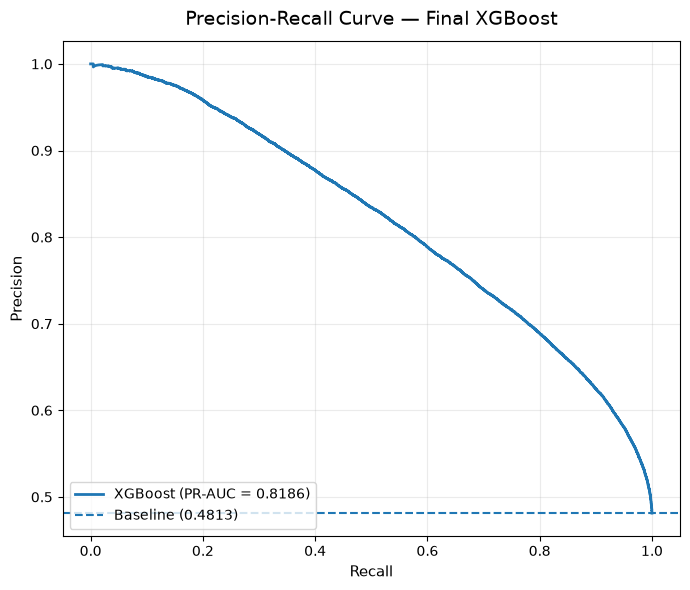

PR-AUC: 0.8186
Positive-class baseline: 0.4813
Figure saved to: ..\reports\figures\08_final_test_evaluation\07_precision_recall_curve.png


In [12]:


# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

# Calculate PR-AUC
pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

# Positive-class baseline
positive_rate = y_test.mean()

# Create output directory
FIGURES_DIR = Path("../reports/figures/08_final_test_evaluation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

# Plot Precision-Recall curve
ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"XGBoost (PR-AUC = {pr_auc:.4f})"
)

# Plot positive-class baseline
ax.axhline(
    positive_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline ({positive_rate:.4f})"
)

ax.set_title(
    "Precision-Recall Curve — Final XGBoost",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)

ax.legend(loc="lower left")

ax.grid(
    True,
    alpha=0.25
)

plt.tight_layout()

# Save figure
FIGURE_PATH = FIGURES_DIR / "07_precision_recall_curve.png"

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"PR-AUC: {pr_auc:.4f}")
print(f"Positive-class baseline: {positive_rate:.4f}")
print(f"Figure saved to: {FIGURE_PATH}")

### Precision-Recall Curve Interpretation

The Precision-Recall curve illustrates the trade-off between correctly identifying deterioration events and maintaining the accuracy of positive predictions as the classification threshold changes.

Higher recall means that the model detects a larger proportion of actual deterioration events, while higher precision means that a larger proportion of the generated deterioration warnings correspond to actual deterioration events.

The horizontal baseline represents the prevalence of deterioration events in the test set. In this test set, the positive-class baseline is **0.4813**. A precision-recall curve that remains substantially above this baseline indicates that the model provides predictive information beyond the underlying class prevalence.


### Findings

The final XGBoost model achieved a **PR-AUC of 0.8186** on the unseen test set.

The PR-AUC is substantially higher than the positive-class baseline of **0.4813**, indicating that the model provides meaningful predictive information for identifying deterioration events beyond the underlying prevalence of the positive class.

The Precision-Recall curve demonstrates the trade-off between detecting more deterioration events and maintaining accurate warnings. Increasing recall generally requires accepting a reduction in precision, while prioritizing higher precision may result in more deterioration events being missed.

For AirShift, this trade-off is particularly important because the system is intended to provide useful early warnings while limiting unnecessary alerts.


## 8. Final Test Findings

The final XGBoost model was evaluated on the held-out test set covering observations from January 2016 to February 2017.

The test set was not used during model development, hyperparameter tuning, or final model training, providing an evaluation of the model's performance on unseen data.

The final evaluation combines the classification metrics, confusion matrix, ROC curve, and Precision-Recall curve to provide an overall assessment of the model's ability to detect air quality deterioration events.


### Final Test Performance

| Metric        |   Test Set |
| ------------- | ---------: |
| **Accuracy**  | **0.7368** |
| **Precision** | **0.7244** |
| **Recall**    | **0.7315** |
| **F1 Score**  | **0.7279** |
| **ROC-AUC**   | **0.8215** |
| **PR-AUC**    | **0.8186** |

The model achieved a **Recall of 0.7315**, meaning that it detected approximately 73% of the actual deterioration events in the test set. Its **Precision of 0.7244** indicates that approximately 72% of the observations classified as deterioration were actual deterioration events.

The **F1 Score of 0.7279** reflects the balance between precision and recall, while the **ROC-AUC of 0.8215** and **PR-AUC of 0.8186** indicate that the model maintains good discrimination and precision-recall performance across different probability thresholds.


### Classification Outcomes

The confusion matrix provides additional insight into the model's classification behavior:

| Classification Outcome  |  Count |
| ----------------------- | -----: |
| **True Negative (TN)**  | 46,896 |
| **False Positive (FP)** | 16,331 |
| **False Negative (FN)** | 15,756 |
| **True Positive (TP)**  | 42,917 |

The model correctly classified **89,813 out of 121,900 test observations**, while **32,087 observations were misclassified**.

For the AirShift early-warning objective, the **15,756 false negatives** are particularly important because they represent deterioration events that were not detected by the model. The model also produced **16,331 false positives**, representing observations for which the model predicted deterioration when no deterioration event was recorded.


### Overall Interpretation

The final XGBoost model demonstrates a consistent ability to identify air quality deterioration events on the unseen test set. The model achieved **0.7368 accuracy**, **0.7244 precision**, **0.7315 recall**, and an **F1 score of 0.7279**.

The **ROC-AUC of 0.8215** indicates good discrimination between deterioration and non-deterioration observations across classification thresholds. Similarly, the **PR-AUC of 0.8186**, substantially above the test-set positive-class baseline of **0.4813**, indicates that the model provides meaningful predictive information for identifying deterioration events.

The results also show a practical trade-off between missed deterioration events and unnecessary warnings. While the model detected a substantial proportion of deterioration events, some events were missed, as reflected by the false negative count. At the same time, the number of false positives indicates that some warnings would not correspond to an observed deterioration event.

Overall, the final test evaluation supports the use of the XGBoost model as a predictive component of the AirShift early-warning system. Further analysis is required to determine which features contribute most to the model's predictions and how much warning lead time can be achieved before a deterioration event occurs.


### Next Step

The next stage is to interpret the final XGBoost model and investigate which features contribute most to its predictions.

This will include feature importance analysis and model interpretation techniques to understand the environmental, meteorological, temporal, and historical pollution patterns associated with predicted deterioration events.
